# <font face = 'Impact' color = '#FFAEBC' > Sample Demonstration on Multiple Regression <font/>
#### <font face = 'Times New Roman' color = '#B5E5CF'> License: GPL v3.0<font/>
#### <font face = 'Times New Roman' color = '#B5E5CF'> Author and Trainer: Paolo Hilado MSc. (Data Science)<font/>
This notebook provides a backgrounder on doing Multiple Regression in Python. From assumption checks to modeling via the Ordinary Least Squares Method, it aims to equip learners with a solid take on learning and applying this data analysis approach for data driven decision making.

# Business Concern
You’re a logistics operations analyst, and you want to understand what factors drive or influence your monthly operational costs, such as:
- How many drivers you employ
- How much time deliveries take
- Vehicle maintenance
- Miles driven

The Logistics Manager asked you the following question:
“Can we explain (and eventually predict or control) our operational costs using these variables?”

In [ ]:
!pip install qdesc

In [ ]:
# Load necessary packages
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import qdesc as qd
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

In [ ]:
# Load the dataframe from LogisticsBusiness.xlsx
# Check out the information about the data frame.
df = pd.read_excel("LogisticsBusiness.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Drivers          150 non-null    int64  
 1   DeliveryTime     150 non-null    float64
 2   MaintenanceCost  150 non-null    float64
 3   MilesDriven      150 non-null    float64
 4   OperationalCost  150 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
# Check out the first 6 rows
df.head(6)

,Drivers,DeliveryTime,MaintenanceCost,MilesDriven,OperationalCost
0,15,1.942589,3037.966131,10013.184538,22109.870670
1,13,2.080372,3021.955471,9960.994202,21471.958115
2,15,1.938657,2954.891493,10114.625032,22099.627854
3,13,2.070277,2961.422523,9756.955716,21332.816212
4,12,1.943140,2981.325092,9923.413388,21132.966142
5,16,1.973226,2927.711934,10360.878319,22508.695889


In [ ]:
# Fit multiple regression model
X = df[['Drivers', 'DeliveryTime', 'MaintenanceCost', 'MilesDriven']]
X = sm.add_constant(X)
y = df['OperationalCost']
model = sm.OLS(y, X).fit()

In [ ]:
# Check Residual Normality - Preparation
residuals = model.resid # retrieve residuals
res = pd.DataFrame(residuals) # convert to dataframe
res.rename(columns={0: 'Residuals'}, inplace=True) # rename columns
res.head()

,Residuals
0,-12.308965
1,-33.971271
2,-4.696092
3,-19.790687
4,-0.434262



--- Variable: Residuals ---
  Anderson-Darling Statistic : 0.3477
  Critical Value (@ 5.0%) : 0.7670
  Decision : Fail to Reject Null


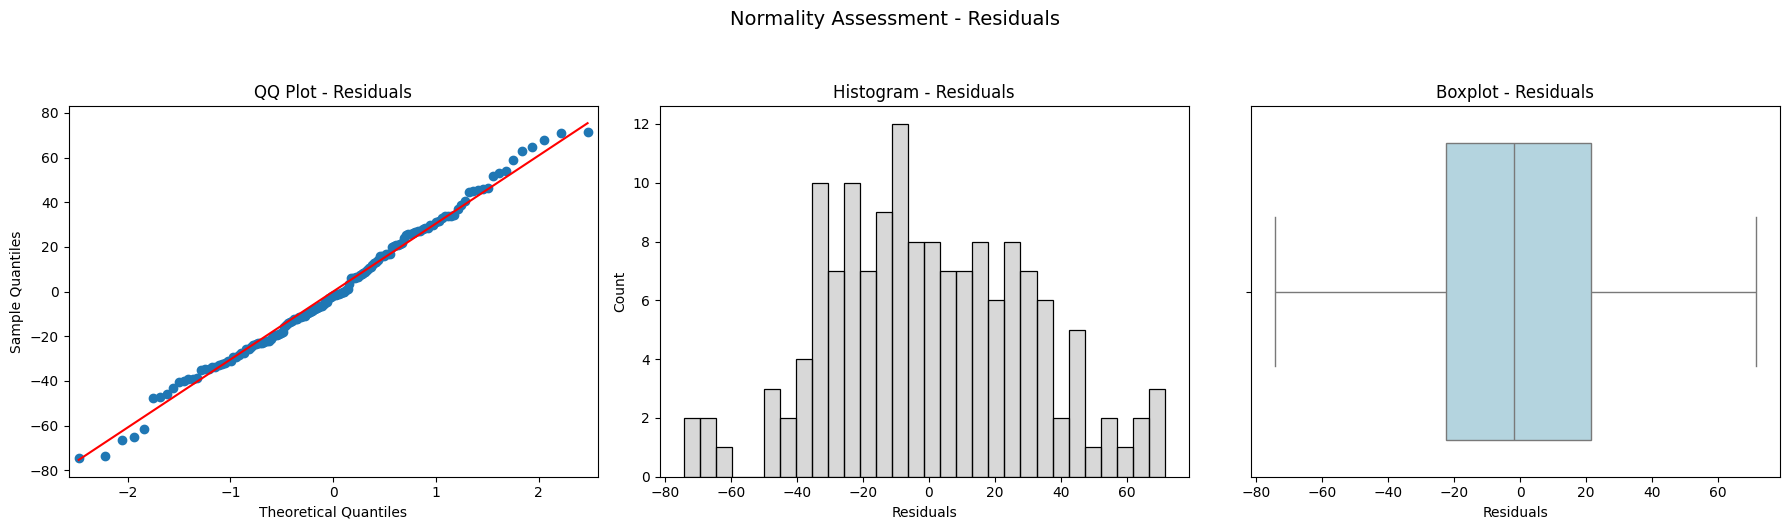

In [ ]:
# Check Residual Normality - Normality Testing
qd.normcheck_dashboard(res)

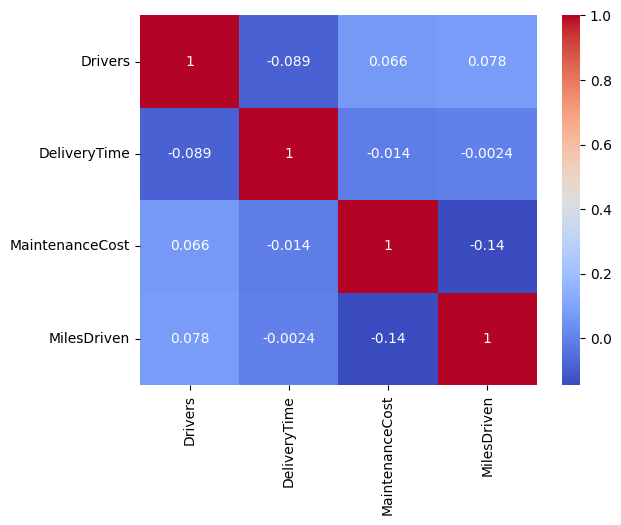

In [ ]:
# Create a heatmap to check for Multicollinearity
sns.heatmap(df[['Drivers', 'DeliveryTime', 'MaintenanceCost', 'MilesDriven']].corr(), annot=True, cmap='coolwarm')
plt.show()

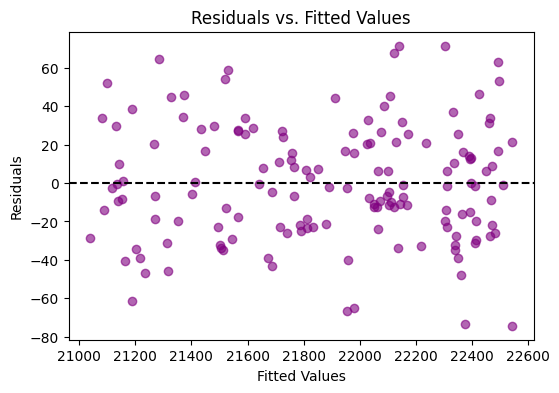

In [ ]:
# Check Homoscedasticity (constant variance of residuals) - Visualization
plt.figure(figsize=(6, 4))
plt.scatter(model.fittedvalues, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.show()

In [ ]:
# Check Homoscedasticity (constant variance of residuals) - Breusch-Pagan test
bp_test = het_breuschpagan(residuals, model.model.exog)
print(f"Breusch-Pagan test p-value: {bp_test[1]:.4f}")
if bp_test[1] > 0.05:
    print("Homoscedasticity assumption holds (fail to reject H0)")
else:
    print("Heteroscedasticity detected (reject H0)")

Breusch-Pagan test p-value: 0.0555
Homoscedasticity assumption holds (fail to reject H0)


In [ ]:
# Retrieve df original variables: 'Drivers', 'DeliveryTime', 'MaintenanceCost', 'MilesDriven'
features = ['Drivers', 'DeliveryTime', 'MaintenanceCost', 'MilesDriven']

# Standardize the explanatory variables
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(df[features]) #convert in dataframe

# Retain original column names
X_scaled = pd.DataFrame(X_scaled_array, columns=features)

# Add intercept
X_scaled = sm.add_constant(X_scaled)

# Fit the model
y = df['OperationalCost']
model_std = sm.OLS(y, X_scaled).fit()

# Print model Summary
print(model_std.summary())


                            OLS Regression Results                            
Dep. Variable:        OperationalCost   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     7475.
Date:                Fri, 10 Oct 2025   Prob (F-statistic):          8.39e-167
Time:                        03:53:44   Log-Likelihood:                -725.20
No. Observations:                 150   AIC:                             1460.
Df Residuals:                     145   BIC:                             1475.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.189e+04      2.528   86